In [1]:
# 1 implementar as operacoes vetoriais de forma vetorizada (vectorized - numpy)
# 2 implementar a mesma com jax  (np -> jnp)

import numpy as np 
import matplotlib.pyplot as plt

A = 1.0 
alpha = 0.7 
gamma = 0.8
epsilon = 0.08
v0 = 0.0
w0 = 0.0
d = 0.01 #difusao


h = 0.1 #passos de tempo
delta_x = 0.1 #passo espacial

xf = 1.0
tf = 20.0 #tempo final

t = np.arange(0, tf + h, h)
x = np.arange(0, xf + delta_x, delta_x)



 

In [2]:
def I_ion(v, w, t, iamp):
    iapp = np.where((t >= 1.0) & (t <= 2.0), iamp, 0.0) #np. where(condicao, valor_se_verdadeiro, valor_se_falso) para cada elemento do vetor t
    return v - (v**3)/3.0 - w + iapp

def g(v,w):
    return epsilon*(v + alpha - gamma*w) 


V = np.zeros((len(t), len(x))) 
W = np.zeros((len(t), len(x)))


#condicoes iniciais
V[0, :] = -1.2 #v0
W[0, :] = -0.62 #w0


# I = 1:Nx-1
estimulo = np.zeros(len(x))
for i in range(len(x)):
    if x[i] <= 0.1:
        estimulo[i] = 5.0
    else:
        estimulo[i] = 0.0


for i in range(len(t) - 1):

    
    dvdt = (d*(V[i,2:] - 2*V[i,1:-1] + V[i,:-2]) / delta_x**2 + I_ion(V[i,1:-1], W[i,1:-1], t[i], estimulo[1:-1]))
    #V[i,2] - todos os nós j+1 , V[i,1:-1] - todos os nós j , V[i,:-2] - todos os nós j-1

    dwdt = g(V[i,1:-1], W[i,1:-1])

    V[i+1,1:-1] = V[i,1:-1] + dvdt * h
    W[i+1,1:-1] = W[i,1:-1] + dwdt * h

    # condições de contorno
    V[i+1, 0] = V[i+1, 1]
    V[i+1, -1] = V[i+1, -2]

    W[i+1, 0] = W[i, 0] + h * g(V[i, 0], W[i, 0])
    W[i+1, -1] = W[i, -1] + h * g(V[i, -1], W[i, -1])



# for i in range(len(t)-1):
#     for j in range(1, len(x)-1):

#         if x[j] <= 0.1:
#             estimulo = 5.0
#         else:            
#             estimulo = 0
       
#         dvdt = d*(V[i,j+1] - 2*V[i,j] +V[i,j-1])/delta_x**2 + I_ion(V[i,j], W[i,j], t[i], estimulo) 
#         #dvdt = I_ion(V[i,j], W[i,j], t[i], estimulo) 

#         dwdt = g(V[i,j], W[i,j])

#         V[i+1,j] = V[i,j] + dvdt * h
#         W[i+1,j] = W[i,j] + dwdt * h

    # #condicoes de contorno
    # V[i+1,0] = V[i+1,1]
    # V[i+1,-1] = V[i+1,-2]

    # W[i+1,0] = W[i,0] + g(V[i,0], W[i,0]) * h
    # W[i+1,-1] = W[i,-1] + g(V[i,-1], W[i,-1]) * h



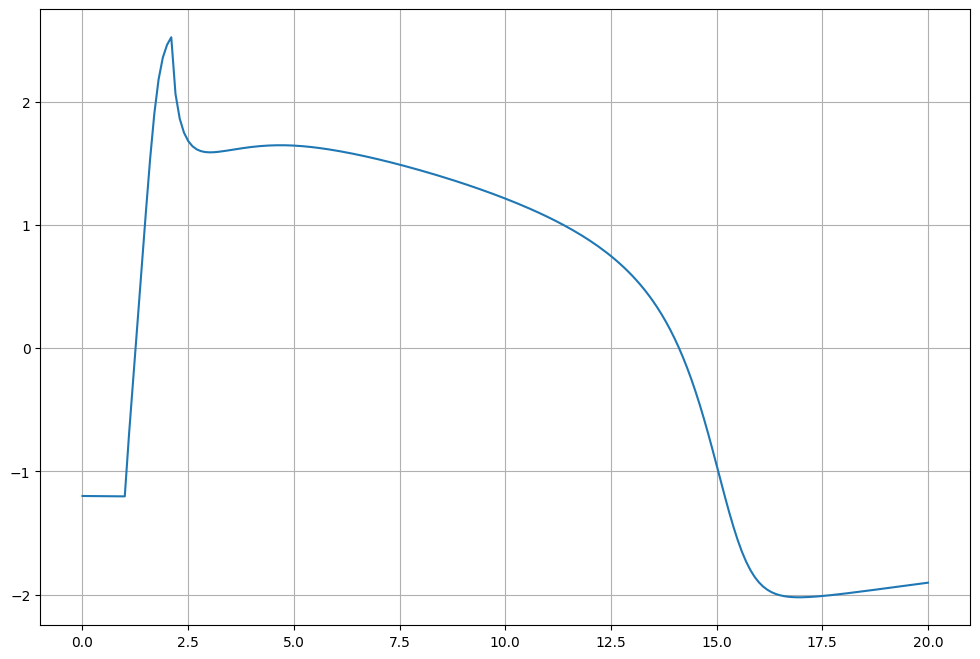

In [3]:

plt.figure(figsize=(12,8))
plt.plot(t,V[:,1])
plt.grid(True)
plt.show()


0
1
5
20
100
200


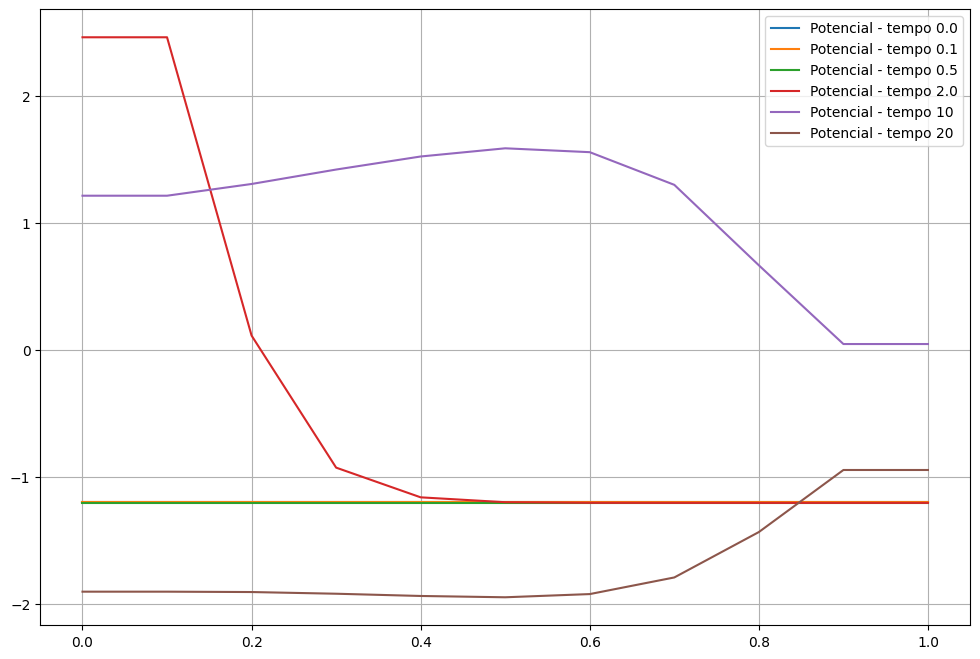

0
1
5
20
100
200


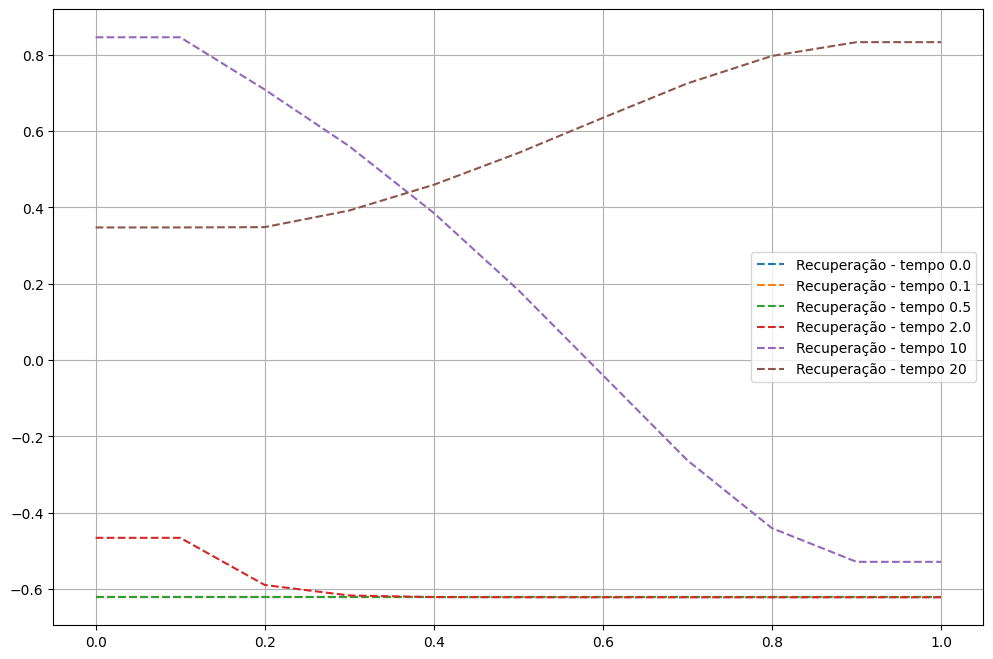

200


In [4]:
t_plot = [0.0, 0.1, 0.5, 2.0,10,20]
plt.figure(figsize=(12,8))
for t in t_plot:
    plt.plot(x,V[int(t/h),:], label = 'Potencial - tempo {}'.format(t))
    #plt.plot(x,W[int(t/h),:], label = 'Recuperação - tempo {}'.format(t), linestyle='--')
    print(int(t/h))
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,8))
for t in t_plot:
    #plt.plot(x,V[int(t/h),:], label = 'Potencial - tempo {}'.format(t))
    plt.plot(x,W[int(t/h),:], label = 'Recuperação - tempo {}'.format(t), linestyle='--')
    print(int(t/h))
plt.legend()
plt.grid(True)
plt.show()

print(int(t/h))